# Text and math

Everything a figure *says*: the face it is set in, the styles you can put on
one word of a label without touching the rest, and the `$…$` mathematics it
typesets with no LaTeX installation anywhere on the machine.

One idea runs through all of it — **it stays text**. A bold number inside a
title, a tinted symbol inside an equation, a rotated axis label: all of it
comes back out of a PDF or an SVG as real, selectable, re-typeable characters
in an embedded subset of the face that drew them. Nothing here is baked into
outlines, and no equation is a picture of an equation.

The other idea is that every label slot takes the same things. `title`,
`xlabel`/`ylabel`, `suptitle`, `xticklabels`, a mark's `label=`, `text` and
`annotate` all accept a plain string, a string with `$…$` in it, or a rich-text
span — and never care which they were given.

In [1]:
import math
import re
import tempfile
from pathlib import Path

import pyplotrs as pp

OUT = Path(tempfile.mkdtemp(prefix="pyplotrs-text-"))

t = [i * 0.15 for i in range(61)]
damped = [math.sin(x) * math.exp(-0.2 * x) for x in t]

print("pyplotrs", pp.__version__)

pyplotrs 0.1.0


## Fonts

`set_font_family` takes a *preference order* and the first face that actually
resolves on the machine wins. It is the one process-wide setting in the
library, deliberately: which fonts exist is a property of the computer, not of
the figure.

Whatever resolves is **embedded in the output**, subset to the glyphs used, so
the file reads identically on a machine that has never heard of that face.

In [2]:
print("preference :", pp.get_font_family())
print("resolved   :", pp.resolved_font_name())
for role, face in pp.resolved_font_variants():
    print(f"  {role:<16}{face}")

preference : ['Arial', 'Helvetica', 'Liberation Sans']
resolved   : Arial
  body            ArialMT
  body-bold       Arial-BoldMT
  body-italic     Arial-ItalicMT
  body-bolditalic Arial-BoldItalicMT


In [3]:
# The last entry of the default order is the Liberation Sans compiled into the
# extension, so there is always a face to fall back to. Here the first name is
# deliberately one nothing has.
pp.set_font_family(["No Such Face", "Liberation Sans"])
print("asked for a font nothing has →", pp.resolved_font_name())

# A preference lasts for the process, so put the default back - otherwise
# every figure below this cell is set in a different face from every figure
# above it.
pp.set_font_family()
print("back to the default order    →", pp.resolved_font_name())

asked for a font nothing has → Liberation Sans
back to the default order    → Arial


Four faces of that family are resolved, not one, and `weight=`/`style=` pick
between them. They are the family's **real** bold and italic — pyplotrs never
synthesizes a slant by shearing the regular face, which is what makes a bold
label look designed rather than smeared.

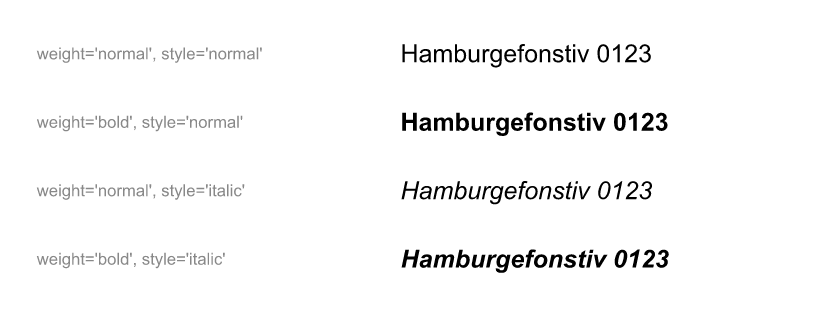

In [4]:
fig, ax = pp.subplots(figsize=(400, 150))
for i, (weight, style) in enumerate([("normal", "normal"), ("bold", "normal"),
                                     ("normal", "italic"), ("bold", "italic")]):
    ax.text(0.03, 4 - i, f"weight={weight!r}, style={style!r}", fontsize=8,
            color="#888", va="center")
    ax.text(0.48, 4 - i, "Hamburgefonstiv 0123", weight=weight, style=style,
            fontsize=12, va="center")
ax.set(xlim=(0, 1), ylim=(0.4, 4.6))
ax.axis("off")
fig

### The minus sign

You type a hyphen; a negative tick label is set with a real U+2212 MINUS SIGN,
a wider mark sitting higher on the line, drawn to match the digits beside it.
`set_unicode_minus(False)` opts out, for the rare consumer that cannot take the
character.

unicode_minus=True  → ['−3', '−2', '−1', '0', '1', '2', '3']
unicode_minus=False → ['-3', '-2', '-1', '0', '1', '2', '3']


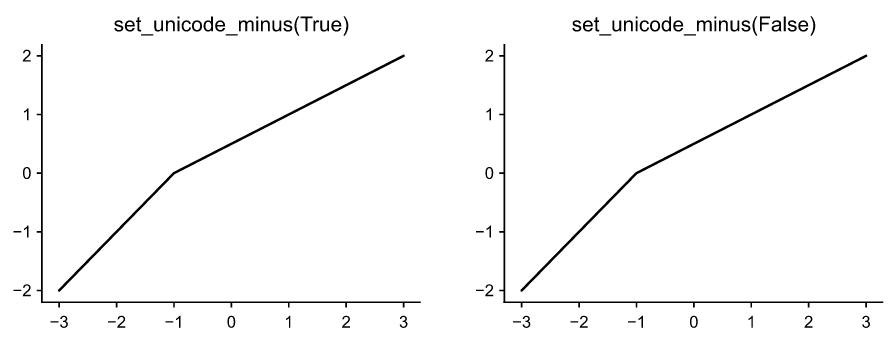

In [5]:
fig, axs = pp.subplots(1, 2, figsize=(430, 165))
for ax, unicode_minus in zip(axs, (True, False)):
    pp.set_unicode_minus(unicode_minus)
    ax.line([-3, -1, 1, 3], [-2, 0, 1, 2])
    ax.set(title=f"set_unicode_minus({unicode_minus})")
    print(f"unicode_minus={unicode_minus!s:<5} → {ax.get_xticklabels()}")

pp.set_unicode_minus(True)
fig

## Putting text on a figure

`text` places a string at a data coordinate; `annotate` points one at a data
coordinate, with an arrow from the label to the point unless you pass
`arrow=False`.

| Argument | Meaning |
|---|---|
| `ha` | `left` (default) / `center` / `right` |
| `va` | `baseline` (default) / `bottom` / `center` / `top` |
| `color` | defaults to the theme's text color |
| `fontsize` | points; defaults to the theme's label size |
| `weight`, `style` | pick a real face of the family, as above |
| `rotation` | degrees counter-clockwise about the anchor |

Rotation is written as a group transform rather than baked into paths, so
rotated text stays selectable in PDF and SVG.

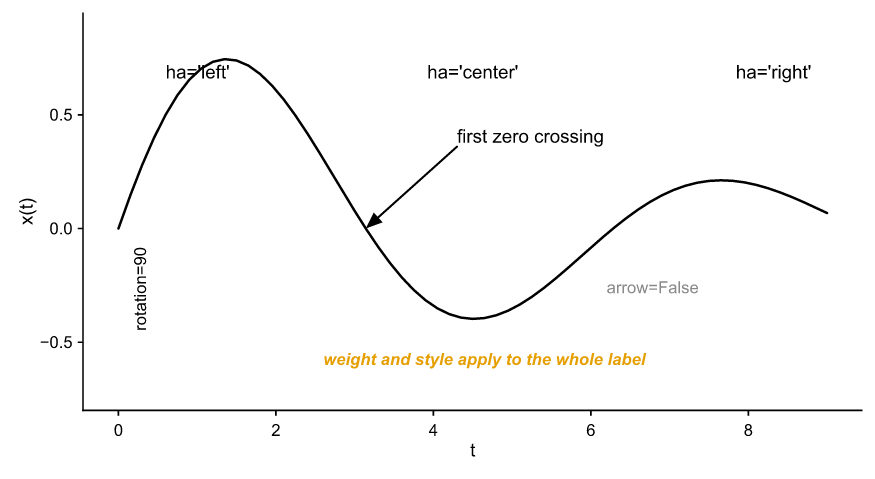

In [6]:
fig, ax = pp.subplots(figsize=(420, 230))
ax.line(t, damped)

ax.text(0.6, 0.66, "ha='left'")
ax.text(4.5, 0.66, "ha='center'", ha="center")
ax.text(8.8, 0.66, "ha='right'", ha="right")
ax.text(0.35, -0.45, "rotation=90", rotation=90, fontsize=8)
ax.text(2.6, -0.6, "weight and style apply to the whole label",
        weight="bold", style="italic", fontsize=8, color="C1")
ax.annotate("first zero crossing", (math.pi, 0.0), xytext=(4.3, 0.36))
ax.annotate("arrow=False", (7.5, 0.2), xytext=(6.2, -0.3), arrow=False,
            fontsize=8, color="#888")

ax.set(ylim=(-0.8, 0.95), xlabel="t", ylabel="x(t)")
fig

Annotations are drawn over the data and take **no part in autoscaling**, so a
label placed outside the data range is clipped rather than stretching the axes
to fit it. Make room with `xlim`/`ylim` when you need it — as the `ylim` above
does.

## Styling part of a label

`weight=` and `style=` are whole-label switches. To emphasize a *substring* —
one number, one word, one term — build the label out of spans instead of out
of a string:

```python
ax.set(title=pp.rich("Growth ", pp.bold("+42%", color="teal"),
                     " over ", pp.italic("6 months")))
```

| Helper | What it gives you |
|---|---|
| `pp.rich(*parts, **style)` | the general span; with no style, just a container |
| `pp.bold(...)`, `pp.italic(...)` | a real face of the family, not a synthetic slant |
| `pp.underline(...)`, `pp.strike(...)` | a rule taken from the face's own metrics |
| `pp.mark(...)` | a highlight panel behind the run |
| `pp.plain(label)` | the styling stripped back off, as a plain string |

The style keys are `weight`, `style`, `color`, `bgcolor`, `underline`,
`strike`, and either `scale` (a multiple of *the label's own* size — usually
what you want, since a title and a tick label are set at different sizes) or
`size` (absolute points). Colors take every spelling the rest of the library
takes, `"C0"` palette indices included, and resolve against the figure's theme
at draw time.

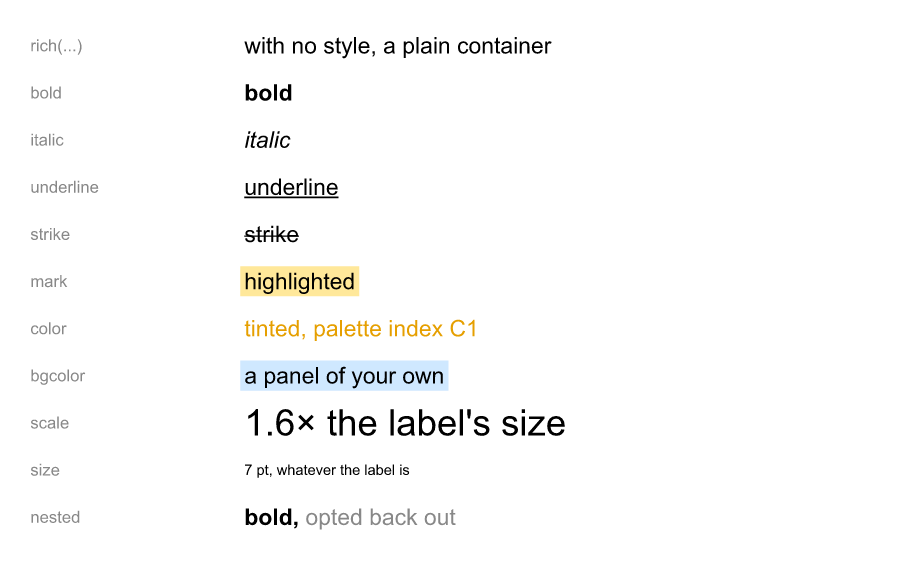

In [7]:
rows = [
    ("rich(...)",  pp.rich("with no style, a plain container")),
    ("bold",       pp.bold("bold")),
    ("italic",     pp.italic("italic")),
    ("underline",  pp.underline("underline")),
    ("strike",     pp.strike("strike")),
    ("mark",       pp.mark("highlighted")),
    ("color",      pp.rich("tinted, palette index C1", color="C1")),
    ("bgcolor",    pp.rich("a panel of your own", bgcolor="#cfe8ff")),
    ("scale",      pp.rich("1.6× the label's size", scale=1.6)),
    ("size",       pp.rich("7 pt, whatever the label is", size=7)),
    ("nested",     pp.bold("bold, ", pp.rich("opted back out", weight="normal",
                                             color="#888"))),
]

fig, ax = pp.subplots(figsize=(440, 270))
for i, (name, span) in enumerate(rows):
    y = len(rows) - i
    ax.text(0.02, y, name, fontsize=8, color="#888", va="center")
    ax.text(0.26, y, span, fontsize=11, va="center")
ax.set(xlim=(0, 1), ylim=(0.3, len(rows) + 0.7))
ax.axis("off")
fig

Spans nest, and an **inner style wins over an outer one**, key by key — which
is what lets a run opt back out of what encloses it rather than only add to
it. `flatten` shows the tree resolved into the runs that will actually be
shaped:

In [8]:
label = pp.bold("all of this ", pp.rich("except this", weight="normal", color="#888"))
for text, style in pp.text.flatten(label):
    print(f"  {text!r:<16}{style}")

# Adjacent runs that end up with the same style are merged back into one, so a
# boundary costs a kern pair only where the style actually changes.
print()
print(pp.text.flatten(pp.rich("a", "b", pp.rich("c"))))
print(pp.text.flatten(pp.rich("a", pp.bold("b"))))

  'all of this '  {'weight': 'bold'}
  'except this'   {'weight': 'normal', 'color': '#888'}

[('abc', {})]
[('a', {}), ('b', {'weight': 'bold'})]


And they work in **every** label slot — a mark's `label=` and so the legend, a
tick label, the figure's `suptitle`, `text` and `annotate`:

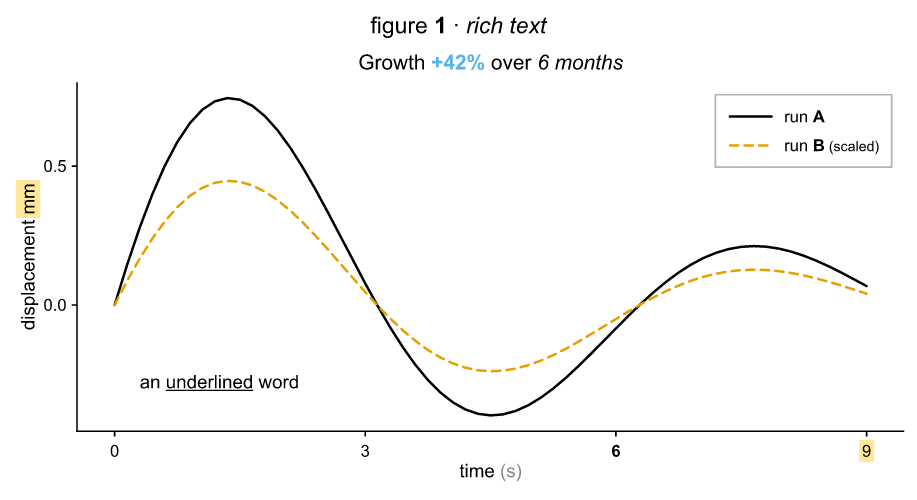

In [9]:
fig, ax = pp.subplots(figsize=(440, 240))
ax.line(t, damped, label=pp.rich("run ", pp.bold("A")))
ax.line(t, [0.6 * y for y in damped], linestyle="dashed",
        label=pp.rich("run ", pp.bold("B"), pp.rich(" (scaled)", scale=0.85)))

ax.set(title=pp.rich("Growth ", pp.bold("+42%", color="C2"),
                     " over ", pp.italic("6 months")),
       xlabel=pp.rich("time ", pp.rich("(s)", color="#888")),
       ylabel=pp.rich("displacement ", pp.mark("mm")),
       xticks=[0, 3, 6, 9],
       xticklabels=["0", "3", pp.bold("6"), pp.mark("9")])
ax.legend()
ax.text(0.3, -0.3, pp.rich("an ", pp.underline("underlined"), " word"), fontsize=9)
fig.set(suptitle=pp.rich("figure ", pp.bold("1"), " · ", pp.italic("rich text")))
fig

A span is a value, not a rendering: it carries its own plain text, and that is
what `get_*` hands back, what the accessible description of a tagged PDF uses,
and what `pp.plain` is for.

In [10]:
title = pp.rich("Growth ", pp.bold("+42%", color="C2"), " over ", pp.italic("6 months"))
fig, ax = pp.subplots(figsize=(300, 160))
ax.line(t, damped)
ax.set(title=title)

print("repr  :", repr(ax.get_title()))
print("plain :", pp.plain(ax.get_title()))
print("str   :", str(title))
print("a plain string is left alone :", repr(pp.plain("already a string")))

# A misspelled style is rejected where you wrote it, rather than quietly doing
# nothing until you notice it in the finished figure.
try:
    pp.rich("x", colour="red")
except TypeError as exc:
    print("\n", exc, sep="")

repr  : rich('Growth ', rich('+42%', color='C2', weight='bold'), ' over ', rich('6 months', style='italic'))
plain : Growth +42% over 6 months
str   : Growth +42% over 6 months
a plain string is left alone : 'already a string'

unknown text style 'colour'; expected any of bgcolor, color, scale, size, strike, style, underline, weight


**Kerning at a style boundary.** Each run is shaped on its own, so a kern pair
that straddles a style change is lost — `pp.rich("W", pp.bold("a"))` sets a
hair wider than `"Wa"`. That is inherent to changing face mid-word, and it
costs nothing where the style does not actually change, because those runs are
merged back into one.

## Mathematics

Anything between `$…$` is typeset by pyplotrs' own engine, driven by the math
font's **OpenType MATH table** — the same positioning constants, italic
corrections and glyph-variant chains a TeX engine uses. **No LaTeX
installation is involved**, and the result stays real text in PDF, SVG and
HTML.

Write the strings raw (`r"..."`) so Python leaves the backslashes alone.

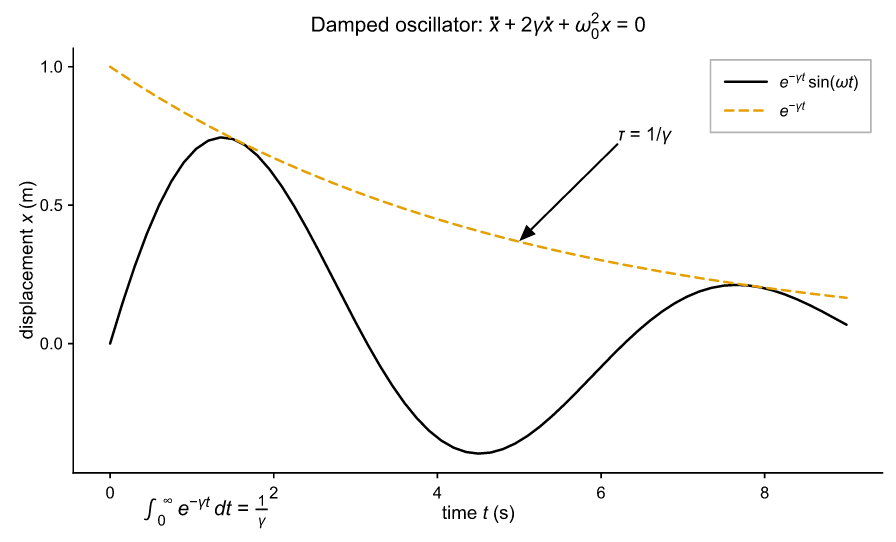

In [11]:
fig, ax = pp.subplots(figsize=(430, 260))

ax.line(t, damped, label=r"$e^{-\gamma t}\sin(\omega t)$")
ax.line(t, [math.exp(-0.2 * x) for x in t], linestyle="dashed",
        label=r"$e^{-\gamma t}$")
ax.set(title=r"Damped oscillator: $\ddot{x} + 2\gamma\dot{x} + \omega_0^2 x = 0$",
       xlabel=r"time $t$ (s)", ylabel=r"displacement $x$ (m)")
ax.legend()

ax.annotate(r"$\tau = 1/\gamma$", (5.0, 0.37), xytext=(6.2, 0.72))
ax.text(0.4, -0.62, r"$\int_0^\infty e^{-\gamma t}\,dt = \frac{1}{\gamma}$",
        fontsize=10)
fig

A tour of the syntax the engine handles:

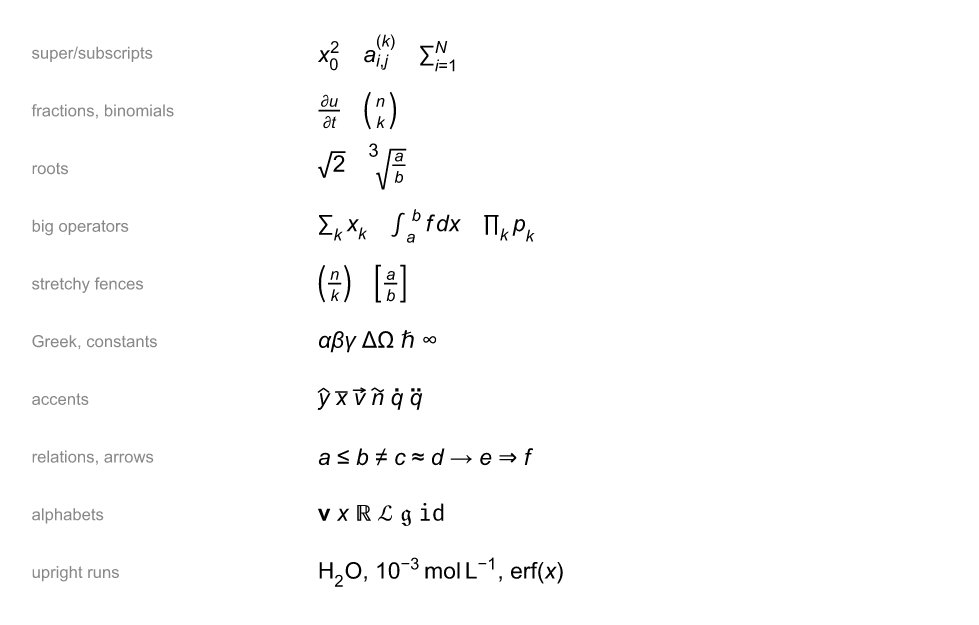

In [12]:
samples = [
    ("super/subscripts",    r"$x_0^2 \quad a_{i,j}^{(k)} \quad \sum_{i=1}^{N}$"),
    ("fractions, binomials", r"$\frac{\partial u}{\partial t} \quad \binom{n}{k}$"),
    ("roots",               r"$\sqrt{2} \quad \sqrt[3]{\frac{a}{b}}$"),
    ("big operators",       r"$\sum_k x_k \quad \int_a^b f\,dx \quad \prod_k p_k$"),
    ("stretchy fences",     r"$\left(\frac{n}{k}\right) \quad \left[\frac{a}{b}\right]$"),
    ("Greek, constants",    r"$\alpha\beta\gamma\;\Delta\Omega\;\hbar\;\infty$"),
    ("accents",             r"$\hat{y}\;\bar{x}\;\vec{v}\;\tilde{n}\;\dot{q}\;\ddot{q}$"),
    ("relations, arrows",   r"$a \leq b \neq c \approx d \to e \Rightarrow f$"),
    ("alphabets",           r"$\mathbf{v}\;\mathit{x}\;\mathbb{R}\;\mathcal{L}\;\mathfrak{g}\;\mathtt{id}$"),
    ("upright runs",        r"$\mathrm{H_2O},\;10^{-3}\,\mathrm{mol\,L^{-1}},\;\operatorname{erf}(x)$"),
]

fig, ax = pp.subplots(figsize=(470, 300))
for i, (name, expression) in enumerate(samples):
    y = len(samples) - i
    ax.text(0.02, y, name, fontsize=8, color="#888", va="center")
    ax.text(0.32, y, expression, fontsize=11, va="center")
ax.set(xlim=(0, 1), ylim=(0.3, len(samples) + 0.7))
ax.axis("off")
fig

### Which face draws what

Math is set in **your own body family**, wherever that family has the glyphs.
Variables and Greek come from its italic, digits and upright roman from the
face the label itself is in, and the common operators (`+ − × ÷ = < > ≤ ≥ ≠ ≈
( ) ∂ ∞ →`) from the same place. So `$\sin\omega t$` is Arial throughout, and a
bold title's math is bold throughout — variables included.

What a text family cannot supply are the parts that have to **grow**: a radical
sized to its content, a `\left(…\right)` fence sized to what it wraps, a `\sum`
enlarged in display style. Growing a glyph needs the variant and assembly
chains of an OpenType MATH table, and no text font has one. Those come from a
bundled *sans* math face, Fira Math, so `√` and `∑` are monoline marks that
match Arial rather than the high-contrast shapes a serif math font draws.

The reason is that a label is read against its neighbors. Drawing all math from
a serif math font makes a log axis label `10³` Times while the y ticks beside it
read `50` and `100` in Arial — and, less obviously, makes `$E = mc^2$` mix a
serif `E m c` with a sans `=` and `2`. This is the same line matplotlib's
default `dejavusans` set draws, for the same reason.

`set_mathtext_fontset` switches the whole thing over to STIX Two Math — the
traditional look, and the right one when your body text is a serif too. It is
pyplotrs' analog of matplotlib's `rcParams["mathtext.fontset"]`, and like
`set_font_family` it is process-wide.

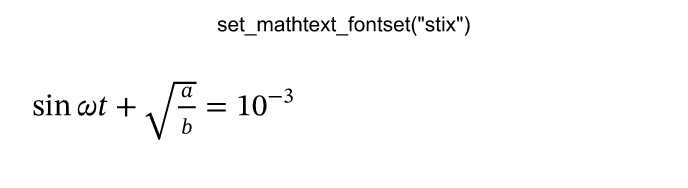

In [13]:
formula = r"$\sin\omega t + \sqrt{\frac{a}{b}} = 10^{-3}$"

pp.set_mathtext_fontset("stix")
fig, ax = pp.subplots(figsize=(330, 90))
ax.text(0.03, 0.5, formula, fontsize=15, va="center")
ax.set(xlim=(0, 1), ylim=(0, 1), title='set_mathtext_fontset("stix")')
ax.axis("off")
fig

fontset: sans


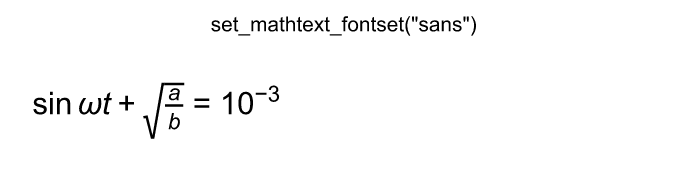

In [14]:
# ...and back. `sans` is the default: the atoms your own family can draw come
# from it, and only what has to grow is left to the math font.
pp.set_mathtext_fontset("sans")
print("fontset:", pp.get_mathtext_fontset())

fig, ax = pp.subplots(figsize=(330, 90))
ax.text(0.03, 0.5, formula, fontsize=15, va="center")
ax.set(xlim=(0, 1), ylim=(0, 1), title='set_mathtext_fontset("sans")')
ax.axis("off")
fig

Two consequences worth knowing: math follows `set_font_family`, so setting
Helvetica makes your variables Helvetica Italic; and saving to `.html`
re-renders the math with an inlined copy of MathJax, which carries its own
serif TeX fonts — so an HTML figure's math will not match the PNG's, though
everything else on the page will.

### Coloring one term

`\textcolor` and `\colorbox` tint *inside* a single expression, and take every
color spelling the rest of the library takes. An unresolvable spec is left
alone and the term is drawn in the ambient color: a typo should cost you a
color, never a term of an equation.

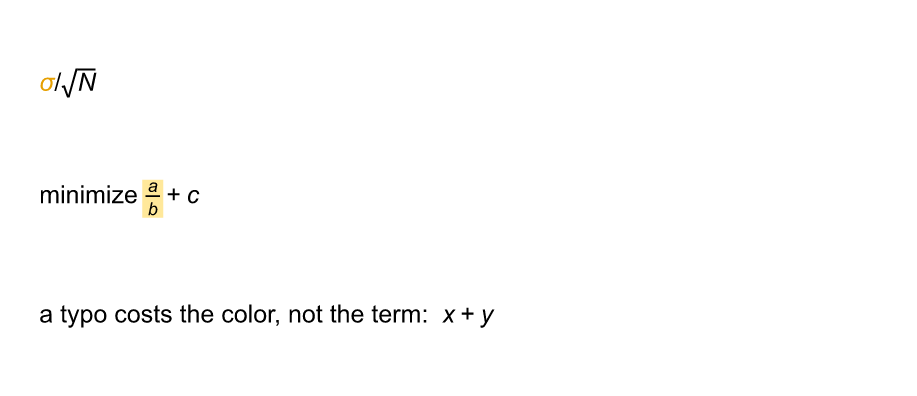

In [15]:
fig, ax = pp.subplots(figsize=(440, 190))
lines = [
    r"$\textcolor{C1}{\sigma} / \sqrt{N}$",
    r"minimize $\colorbox{#ffe89a}{\frac{a}{b}} + c$",
    r"a typo costs the color, not the term:  $\textcolor{nosuchcolor}{x} + y$",
]
for i, line in enumerate(lines):
    ax.text(0.03, len(lines) - i, line, fontsize=12, va="center")
ax.set(xlim=(0, 1), ylim=(0.4, len(lines) + 0.6))
ax.axis("off")
fig

### Math in a tick label

Tick labels are labels, so they take math too — which is how a log axis writes
its decades as `$10^{k}$` without being asked.

the locator wrote: ['$10^{0}$', '$10^{1}$', '$10^{2}$', '$10^{3}$', '$10^{4}$']


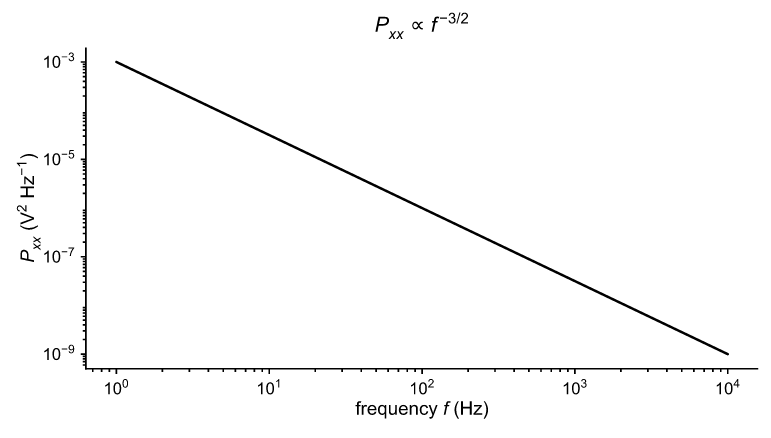

In [16]:
fig, ax = pp.subplots(figsize=(370, 210))
freq = [10 ** (i / 8) for i in range(33)]
ax.line(freq, [1e-3 * f ** -1.5 for f in freq])
ax.set(xscale="log", yscale="log",
       xlabel=r"frequency $f$ (Hz)", ylabel=r"$P_{xx}$ (V$^2$ Hz$^{-1}$)",
       title=r"$P_{xx} \propto f^{-3/2}$")
print("the locator wrote:", ax.get_xticklabels())
fig

### Rich text and math together

A span may contain `$…$`, and the span's weight and slant become the **ambient
face** the math is set in — so `pp.bold(r"$E = mc^2$")` comes out bold
throughout, variables included, rather than half-bold.

Emphasis *within* math has a second spelling that means something different.
`$\mathbf{v}$` selects the math **alphabet** — an upright bold vector, part of
the notation. `pp.bold("$v$")` changes the face the whole span is set in — part
of the typography. Reach for whichever one you actually mean.

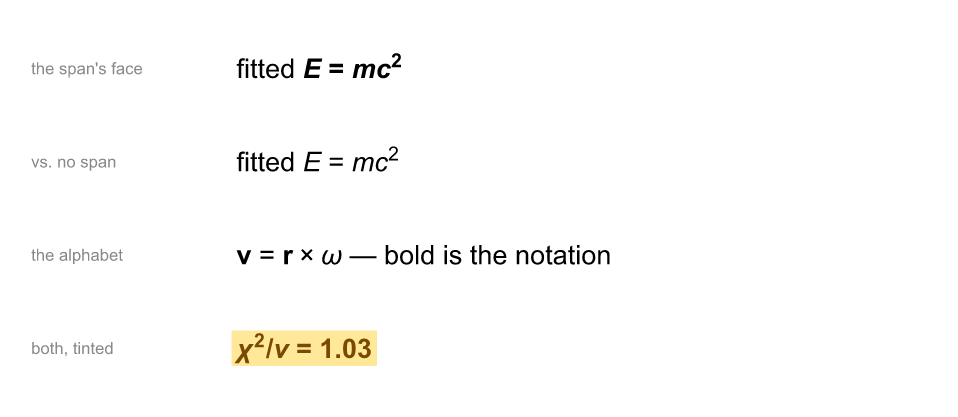

In [17]:
fig, ax = pp.subplots(figsize=(460, 200))
rows = [
    ("the span's face",  pp.rich("fitted ", pp.bold(r"$E = mc^2$"))),
    ("vs. no span",      pp.rich("fitted ", r"$E = mc^2$")),
    ("the alphabet",     pp.rich(r"$\mathbf{v} = \mathbf{r}\times\omega$",
                                 " — bold is the notation")),
    ("both, tinted",     pp.mark(pp.bold(r"$\chi^2/\nu = 1.03$"), color="#7a4a00")),
]
for i, (name, span) in enumerate(rows):
    y = len(rows) - i
    ax.text(0.02, y, name, fontsize=8, color="#888", va="center")
    ax.text(0.24, y, span, fontsize=13, va="center")
ax.set(xlim=(0, 1), ylim=(0.4, len(rows) + 0.6))
ax.axis("off")
fig

## It is still text

That is the claim the whole chapter rests on, so here it is checked — on the
part that is specific to this notebook. A label built from spans is drawn as
several runs, one per style, and the risk that introduces is that the *label*
stops existing: four `<text>` elements where there used to be one string, with
nothing tying them back together for a reader, a screen reader, or a
copy-paste.

The figure below has a partly-bold title, an italic run, a highlight and a
`$…$` axis label. Every run comes out as text, and the runs of one label still
concatenate, in order, back into the string you passed.

(What a saved PDF structurally guarantees — an embedded subset, no Type 3, a
`ToUnicode` map — is checked in
[output formats and performance](08_output_and_performance.ipynb), and holds
for these labels the same as for any other.)

In [18]:
title = pp.rich("Growth ", pp.bold("+42%"), " over ", pp.italic("6 months"))

fig, ax = pp.subplots(figsize=(380, 230))
ax.line(t, damped, label=pp.rich("run ", pp.bold("A")))
ax.legend()
ax.set(title=title, xlabel=r"time $t$ (s)",
       ylabel=pp.rich("displacement ", pp.mark("mm")))
fig.save(str(OUT / "text.svg"))

runs = re.findall(r"<text[^>]*>([^<]*)</text>", (OUT / "text.svg").read_text())
print(f"{len(runs)} <text> elements, and no glyph anywhere turned into a path:")
print(f"  {runs}")

# The title changes style three times, so it is drawn as four of those runs.
# They are still in reading order, and they still spell the label.
plain = pp.plain(title)
joined = "".join(runs)
at = joined.index(plain)
print(f"\nthe styled title, reassembled from the file: {joined[at:at + len(plain)]!r}")
print(f"unchanged from what was passed in           : {plain!r}")

18 <text> elements, and no glyph anywhere turned into a path:
  ['0', '2', '4', '6', '8', '0.0', '0.5', 'Growth ', '+42%', ' over ', '6 months', 'time ', 't', ' (s)', 'displacement ', 'mm', 'run ', 'A']

the styled title, reassembled from the file: 'Growth +42% over 6 months'
unchanged from what was passed in           : 'Growth +42% over 6 months'


## What to reach for

| You want | Write |
|---|---|
| A whole label bold or italic | `weight="bold"`, `style="italic"` |
| One word of it emphasized | `pp.rich(...)` with `pp.bold` / `pp.italic` inside |
| One term of it called out | `pp.mark(...)`, or `color=` on a span |
| A unit or a qualifier set smaller | `pp.rich("…", scale=0.85)` |
| An equation | `$…$` in any label, as a raw string |
| One term of an equation tinted | `\textcolor{C1}{…}` inside the math |
| Bold as part of the notation | `$\mathbf{v}$` |
| Bold as part of the typography | `pp.bold(r"$v$")` |
| Serif math throughout | `pp.set_mathtext_fontset("stix")` |
| The characters back, without the styling | `pp.plain(label)` |

**Next:** [animation](07_animation.ipynb) — the same figures, one per frame.